In [1]:
import numpy as np
import pynumdiff

from pynumdiff.utils import simulate, evaluate

# Generate testing data

Here we amplify the usual signal to get outside the -pi to pi bound.

In [2]:
gain = 4 # amplify signal so it crosses ±pi
noise_type = 'normal' # noise is generated using np.random, e.g. 'normal', 'uniform', 'poisson'
noise_parameters = [0, 0.5/gain] # compatible with np.random functions 
dt = 0.01 # step size and series length in terms of independent variable
duration = 4

In [3]:
x, x_truth, dxdt_truth = simulate.lorenz_x(duration=duration, dt=dt, outliers=False,
                                           noise_type=noise_type, noise_parameters=noise_parameters)
x *= gain; x_truth *= gain; dxdt_truth *= gain

# wrap to [-pi, pi]
x = (x + np.pi) % (2*np.pi) - np.pi
x_truth = (x_truth + np.pi) % (2*np.pi) - np.pi

# Naive numerical differentiation (without considering wrapping)

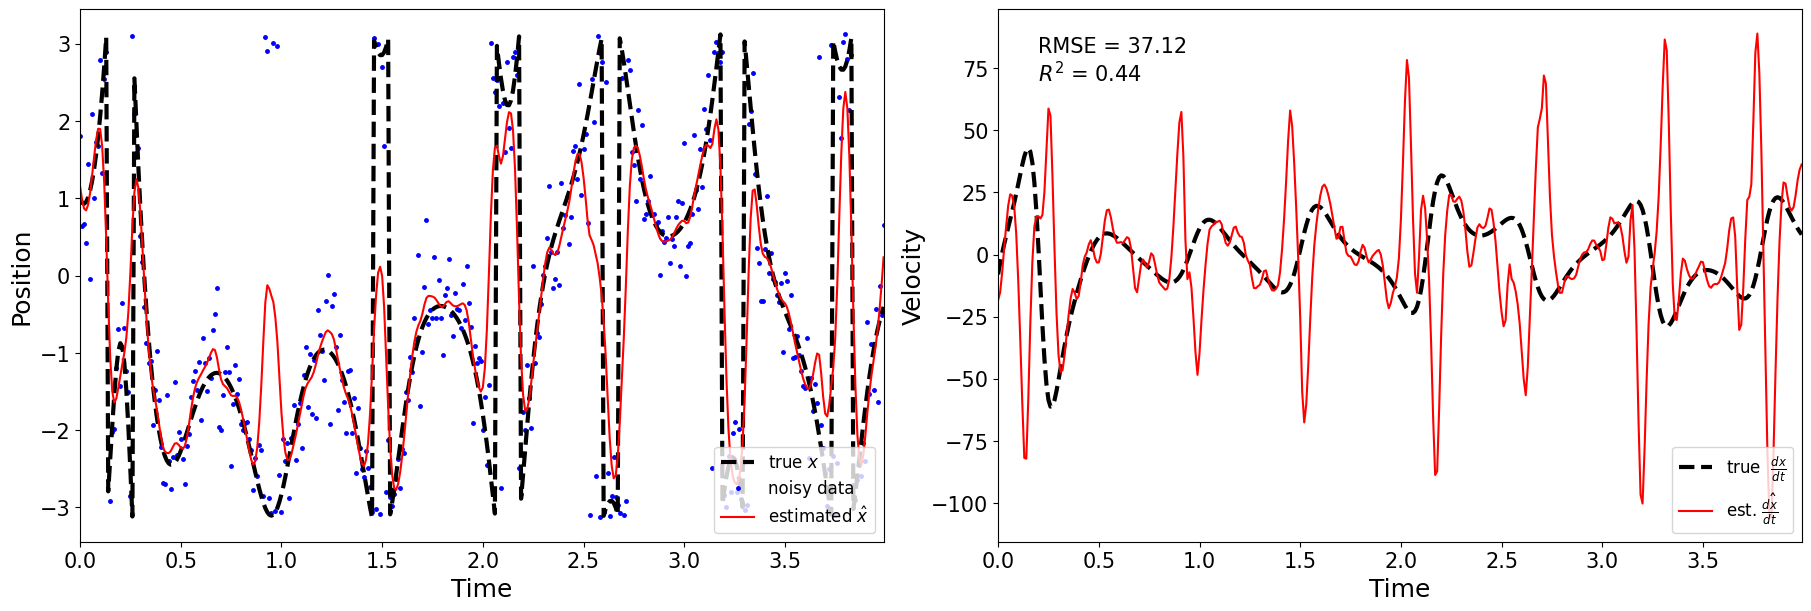

In [4]:
x_hat, dxdt_hat = pynumdiff.kalman_smooth.rtsdiff(x, dt, order=1, log_qr_ratio=5, axis=0, circular=False)

evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);

# Now with circular=True


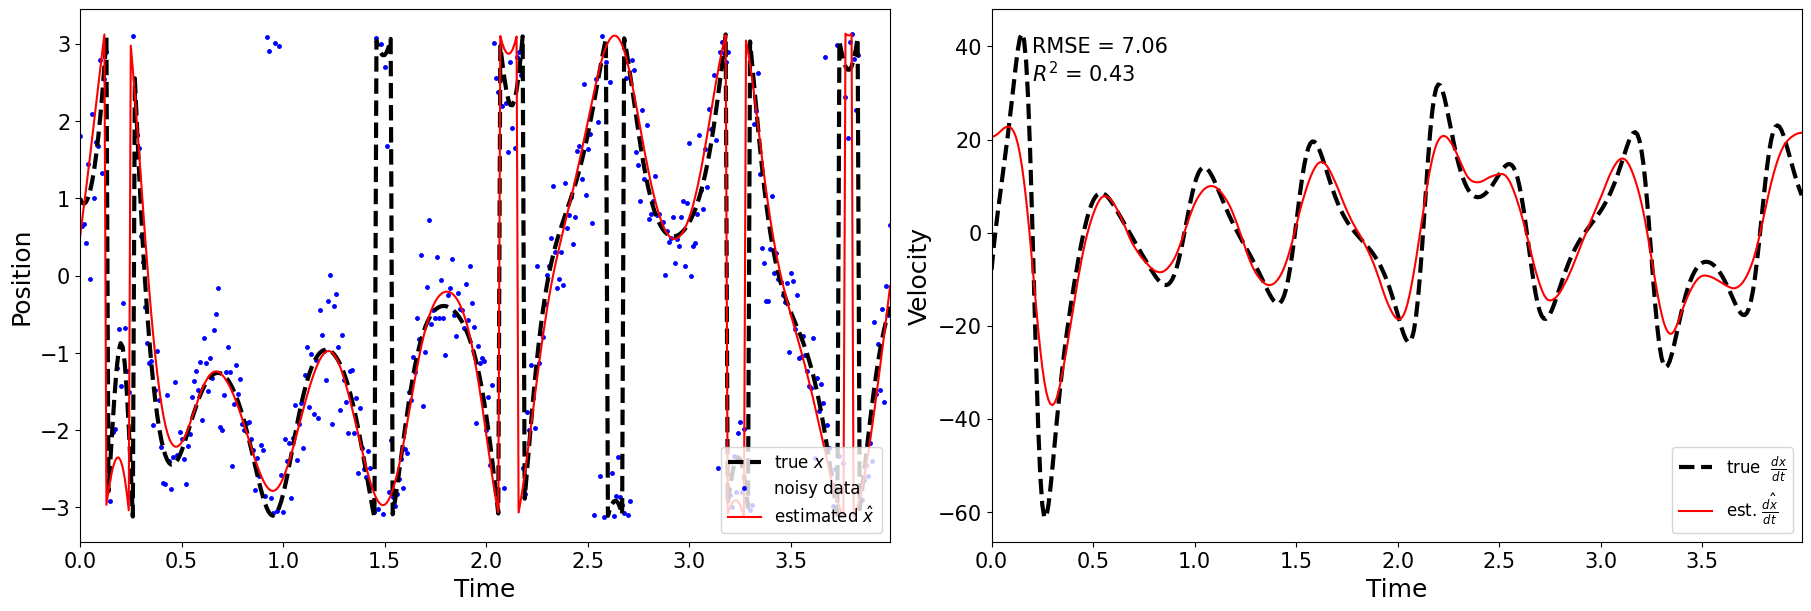

In [5]:
x_hat, dxdt_hat = pynumdiff.kalman_smooth.rtsdiff(x, dt, order=1, log_qr_ratio=3, circular=True)

evaluate.plot(x, dt, x_hat, dxdt_hat, x_truth, dxdt_truth);